## 1. Environment Setup and Data Loading

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
from catboost import CatBoostRegressor
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility	
np.random.seed(42)

# Configure plotting style for academic presentation
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['lines.markersize'] = 6

print("Environment configured successfully.")

Environment configured successfully.


In [3]:
# Load and preprocess dataset
df = pd.read_csv("../assets/realtor-data.zip.csv")

# Subsample for computational efficiency
df = df.sample(n=10000, random_state=42)

print(f"Dataset shape: {df.shape}")
print(f"\nTarget variable (price) statistics:")
print(df['price'].describe())

Dataset shape: (10000, 12)

Target variable (price) statistics:
count    9.991000e+03
mean     5.316304e+05
std      1.398862e+06
min      1.000000e+00
25%      1.649000e+05
50%      3.250000e+05
75%      5.490000e+05
max      7.500000e+07
Name: price, dtype: float64


## 2. Data Preprocessing and Log Transformation

In [4]:
# Handle missing values
df['brokered_by'] = df['brokered_by'].fillna('Unknown')
df['price'] = df['price'].fillna(df['price'].median())
df['bed'] = df['bed'].fillna(df['bed'].median())
df['bath'] = df['bath'].fillna(df['bath'].median())
df['acre_lot'] = df['acre_lot'].fillna(df['acre_lot'].median())
df['street'] = df['street'].fillna('Unknown')
df['city'] = df['city'].fillna('Unknown')
df['zip_code'] = df['zip_code'].fillna('Unknown')
df['house_size'] = df['house_size'].fillna(df['house_size'].median())
df['prev_sold_date'] = df['prev_sold_date'].fillna('Unknown')

print(f"Missing values after imputation:\n{df.isnull().sum()}")

Missing values after imputation:
brokered_by       0
status            0
price             0
bed               0
bath              0
acre_lot          0
street            0
city              0
state             0
zip_code          0
house_size        0
prev_sold_date    0
dtype: int64


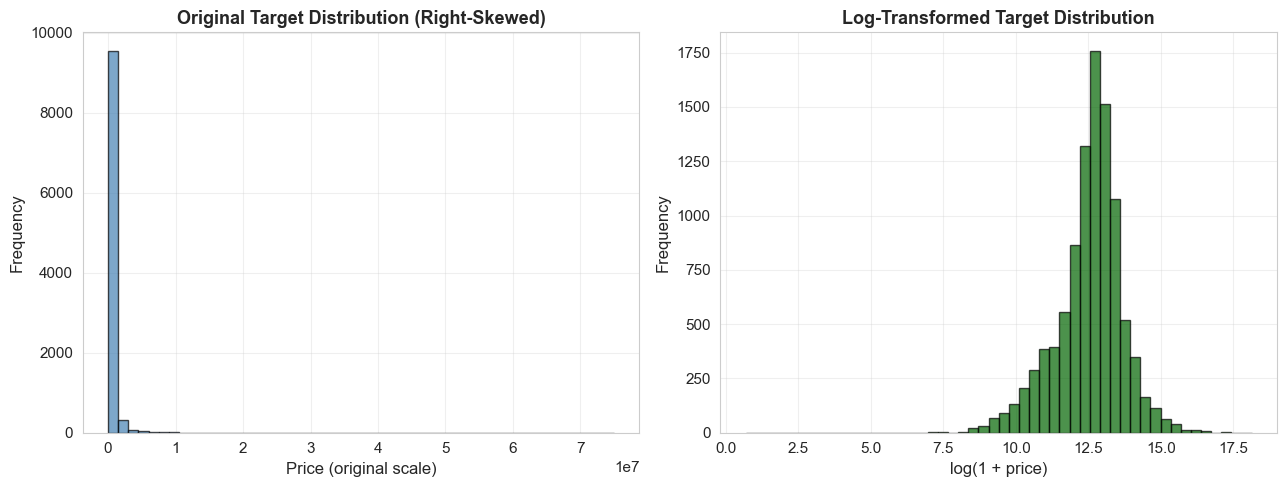

Original target skewness: 25.3114
Log-transformed target skewness: -0.7044


In [5]:
# Visualize target distribution before and after transformation
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Original distribution
axes[0].hist(df['price'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Price (original scale)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Original Target Distribution (Right-Skewed)', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Log-transformed distribution
log_price = np.log1p(df['price'])
axes[1].hist(log_price, bins=50, color='darkgreen', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('log(1 + price)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Log-Transformed Target Distribution', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Original target skewness: {df['price'].skew():.4f}")
print(f"Log-transformed target skewness: {log_price.skew():.4f}")

In [6]:
# Apply log transformation to target
y = np.log1p(df['price'])
X = df.drop('price', axis=1)

# Label encode categorical features
categorical_features = ['brokered_by', 'status', 'street', 'city', 'state', 'zip_code', 'prev_sold_date']
le_dict = {}

X_encoded = X.copy()
for col in categorical_features:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X[col].astype(str))
    le_dict[col] = le

# Train-validation-test split (60% train, 20% validation, 20% test)
X_temp, X_test, y_temp, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42
)

print(f"Train set size: {X_train.shape[0]}")
print(f"Validation set size: {X_val.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"\nFeatures: {X_train.shape[1]}")

Train set size: 6000
Validation set size: 2000
Test set size: 2000

Features: 11


## 3. Hyperparameter Configuration

In [7]:
# Define hyperparameter grids for sensitivity analysis

# XGBoost hyperparameter ranges
xgb_params = {
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7, 9],
    'n_estimators': [50, 100, 200, 300],
    'subsample': [0.6, 0.8, 0.9, 1.0]
}

# CatBoost hyperparameter ranges
cat_params = {
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'depth': [3, 5, 7, 9],
    'iterations': [50, 100, 200, 300],
    'l2_leaf_reg': [1.0, 3.0, 5.0, 10.0]
}

print("XGBoost hyperparameter ranges:")
for param, values in xgb_params.items():
    print(f"  {param}: {values}")

print("\nCatBoost hyperparameter ranges:")
for param, values in cat_params.items():
    print(f"  {param}: {values}")

XGBoost hyperparameter ranges:
  learning_rate: [0.01, 0.05, 0.1, 0.2]
  max_depth: [3, 5, 7, 9]
  n_estimators: [50, 100, 200, 300]
  subsample: [0.6, 0.8, 0.9, 1.0]

CatBoost hyperparameter ranges:
  learning_rate: [0.01, 0.05, 0.1, 0.2]
  depth: [3, 5, 7, 9]
  iterations: [50, 100, 200, 300]
  l2_leaf_reg: [1.0, 3.0, 5.0, 10.0]


## 4. Benchmark Experiments: One-Dimensional Sensitivity Analysis

In [8]:
# Storage for results across varying learning rates
xgb_lr_results = {'learning_rate': [], 'rmse_log': [], 'mae_original': [], 'r2': []}
cat_lr_results = {'learning_rate': [], 'rmse_log': [], 'mae_original': [], 'r2': []}

print("="*70)
print("SENSITIVITY ANALYSIS: Learning Rate Variation")
print("="*70)

# Fixed baseline: depth=5, n_estimators=100, subsample/l2_leaf_reg=default
for lr in xgb_params['learning_rate']:
    # XGBoost
    xgb_model = xgb.XGBRegressor(
        learning_rate=lr,
        max_depth=5,
        n_estimators=100,
        subsample=0.9,
        random_state=42,
        verbosity=0
    )
    xgb_model.fit(X_train, y_train)
    y_pred_val = xgb_model.predict(X_val)
    
    rmse_log = np.sqrt(mean_squared_error(y_val, y_pred_val))
    mae_orig = mean_absolute_error(np.expm1(y_val), np.expm1(y_pred_val))
    r2 = r2_score(y_val, y_pred_val)
    
    xgb_lr_results['learning_rate'].append(lr)
    xgb_lr_results['rmse_log'].append(rmse_log)
    xgb_lr_results['mae_original'].append(mae_orig)
    xgb_lr_results['r2'].append(r2)
    
    print(f"XGBoost (lr={lr:5.3f}): RMSE_log={rmse_log:.6f}, MAE_orig={mae_orig:.2f}, R²={r2:.6f}")

for lr in cat_params['learning_rate']:
    # CatBoost
    cat_model = CatBoostRegressor(
        learning_rate=lr,
        depth=5,
        iterations=100,
        l2_leaf_reg=1.0,
        random_state=42,
        verbose=0,
        allow_writing_files=False
    )
    cat_model.fit(X_train, y_train, cat_features=categorical_features if categorical_features else None)
    y_pred_val = cat_model.predict(X_val)
    
    rmse_log = np.sqrt(mean_squared_error(y_val, y_pred_val))
    mae_orig = mean_absolute_error(np.expm1(y_val), np.expm1(y_pred_val))
    r2 = r2_score(y_val, y_pred_val)
    
    cat_lr_results['learning_rate'].append(lr)
    cat_lr_results['rmse_log'].append(rmse_log)
    cat_lr_results['mae_original'].append(mae_orig)
    cat_lr_results['r2'].append(r2)
    
    print(f"CatBoost  (lr={lr:5.3f}): RMSE_log={rmse_log:.6f}, MAE_orig={mae_orig:.2f}, R²={r2:.6f}")

print("\nLearning rate sensitivity analysis complete.")

SENSITIVITY ANALYSIS: Learning Rate Variation
XGBoost (lr=0.010): RMSE_log=0.839484, MAE_orig=288012.68, R²=0.435489
XGBoost (lr=0.050): RMSE_log=0.711273, MAE_orig=246157.06, R²=0.594752
XGBoost (lr=0.100): RMSE_log=0.691423, MAE_orig=241117.53, R²=0.617055
XGBoost (lr=0.200): RMSE_log=0.687078, MAE_orig=243691.13, R²=0.621853
CatBoost  (lr=0.010): RMSE_log=0.884642, MAE_orig=300268.41, R²=0.373123
CatBoost  (lr=0.050): RMSE_log=0.734982, MAE_orig=258379.10, R²=0.567285
CatBoost  (lr=0.100): RMSE_log=0.710605, MAE_orig=249887.17, R²=0.595513
CatBoost  (lr=0.200): RMSE_log=0.699159, MAE_orig=245753.92, R²=0.608439

Learning rate sensitivity analysis complete.


In [9]:
# Storage for results across varying tree depth
xgb_depth_results = {'depth': [], 'rmse_log': [], 'mae_original': [], 'r2': []}
cat_depth_results = {'depth': [], 'rmse_log': [], 'mae_original': [], 'r2': []}

print("="*70)
print("SENSITIVITY ANALYSIS: Tree Depth Variation")
print("="*70)

# Fixed baseline: learning_rate=0.1, n_estimators=100, subsample/l2_leaf_reg=default
for depth in xgb_params['max_depth']:
    # XGBoost
    xgb_model = xgb.XGBRegressor(
        learning_rate=0.1,
        max_depth=depth,
        n_estimators=100,
        subsample=0.9,
        random_state=42,
        verbosity=0
    )
    xgb_model.fit(X_train, y_train)
    y_pred_val = xgb_model.predict(X_val)
    
    rmse_log = np.sqrt(mean_squared_error(y_val, y_pred_val))
    mae_orig = mean_absolute_error(np.expm1(y_val), np.expm1(y_pred_val))
    r2 = r2_score(y_val, y_pred_val)
    
    xgb_depth_results['depth'].append(depth)
    xgb_depth_results['rmse_log'].append(rmse_log)
    xgb_depth_results['mae_original'].append(mae_orig)
    xgb_depth_results['r2'].append(r2)
    
    print(f"XGBoost (depth={depth}): RMSE_log={rmse_log:.6f}, MAE_orig={mae_orig:.2f}, R²={r2:.6f}")

for depth in cat_params['depth']:
    # CatBoost
    cat_model = CatBoostRegressor(
        learning_rate=0.1,
        depth=depth,
        iterations=100,
        l2_leaf_reg=1.0,
        random_state=42,
        verbose=0,
        allow_writing_files=False
    )
    cat_model.fit(X_train, y_train, cat_features=categorical_features if categorical_features else None)
    y_pred_val = cat_model.predict(X_val)
    
    rmse_log = np.sqrt(mean_squared_error(y_val, y_pred_val))
    mae_orig = mean_absolute_error(np.expm1(y_val), np.expm1(y_pred_val))
    r2 = r2_score(y_val, y_pred_val)
    
    cat_depth_results['depth'].append(depth)
    cat_depth_results['rmse_log'].append(rmse_log)
    cat_depth_results['mae_original'].append(mae_orig)
    cat_depth_results['r2'].append(r2)
    
    print(f"CatBoost  (depth={depth}): RMSE_log={rmse_log:.6f}, MAE_orig={mae_orig:.2f}, R²={r2:.6f}")

print("\nTree depth sensitivity analysis complete.")

SENSITIVITY ANALYSIS: Tree Depth Variation
XGBoost (depth=3): RMSE_log=0.726228, MAE_orig=254205.26, R²=0.577532
XGBoost (depth=5): RMSE_log=0.691423, MAE_orig=241117.53, R²=0.617055
XGBoost (depth=7): RMSE_log=0.706721, MAE_orig=242237.10, R²=0.599923
XGBoost (depth=9): RMSE_log=0.720297, MAE_orig=250861.39, R²=0.584405
CatBoost  (depth=3): RMSE_log=0.736771, MAE_orig=260522.47, R²=0.565177
CatBoost  (depth=5): RMSE_log=0.710605, MAE_orig=249887.17, R²=0.595513
CatBoost  (depth=7): RMSE_log=0.698483, MAE_orig=248017.54, R²=0.609196
CatBoost  (depth=9): RMSE_log=0.699484, MAE_orig=251400.08, R²=0.608074

Tree depth sensitivity analysis complete.


In [10]:
# Storage for results across varying n_estimators/iterations
xgb_est_results = {'n_estimators': [], 'rmse_log': [], 'mae_original': [], 'r2': []}
cat_est_results = {'iterations': [], 'rmse_log': [], 'mae_original': [], 'r2': []}

print("="*70)
print("SENSITIVITY ANALYSIS: Number of Estimators Variation")
print("="*70)

# Fixed baseline: learning_rate=0.1, depth=5, subsample/l2_leaf_reg=default
for n_est in xgb_params['n_estimators']:
    # XGBoost
    xgb_model = xgb.XGBRegressor(
        learning_rate=0.1,
        max_depth=5,
        n_estimators=n_est,
        subsample=0.9,
        random_state=42,
        verbosity=0
    )
    xgb_model.fit(X_train, y_train)
    y_pred_val = xgb_model.predict(X_val)
    
    rmse_log = np.sqrt(mean_squared_error(y_val, y_pred_val))
    mae_orig = mean_absolute_error(np.expm1(y_val), np.expm1(y_pred_val))
    r2 = r2_score(y_val, y_pred_val)
    
    xgb_est_results['n_estimators'].append(n_est)
    xgb_est_results['rmse_log'].append(rmse_log)
    xgb_est_results['mae_original'].append(mae_orig)
    xgb_est_results['r2'].append(r2)
    
    print(f"XGBoost (n_est={n_est:3d}): RMSE_log={rmse_log:.6f}, MAE_orig={mae_orig:.2f}, R²={r2:.6f}")

for n_iter in cat_params['iterations']:
    # CatBoost
    cat_model = CatBoostRegressor(
        learning_rate=0.1,
        depth=5,
        iterations=n_iter,
        l2_leaf_reg=1.0,
        random_state=42,
        verbose=0,
        allow_writing_files=False
    )
    cat_model.fit(X_train, y_train, cat_features=categorical_features if categorical_features else None)
    y_pred_val = cat_model.predict(X_val)
    
    rmse_log = np.sqrt(mean_squared_error(y_val, y_pred_val))
    mae_orig = mean_absolute_error(np.expm1(y_val), np.expm1(y_pred_val))
    r2 = r2_score(y_val, y_pred_val)
    
    cat_est_results['iterations'].append(n_iter)
    cat_est_results['rmse_log'].append(rmse_log)
    cat_est_results['mae_original'].append(mae_orig)
    cat_est_results['r2'].append(r2)
    
    print(f"CatBoost  (iter={n_iter:3d}): RMSE_log={rmse_log:.6f}, MAE_orig={mae_orig:.2f}, R²={r2:.6f}")

print("\nNumber of estimators sensitivity analysis complete.")

SENSITIVITY ANALYSIS: Number of Estimators Variation
XGBoost (n_est= 50): RMSE_log=0.709906, MAE_orig=245683.86, R²=0.596309
XGBoost (n_est=100): RMSE_log=0.691423, MAE_orig=241117.53, R²=0.617055
XGBoost (n_est=200): RMSE_log=0.689630, MAE_orig=239745.70, R²=0.619039
XGBoost (n_est=300): RMSE_log=0.689251, MAE_orig=241323.02, R²=0.619458
CatBoost  (iter= 50): RMSE_log=0.738892, MAE_orig=259962.17, R²=0.562669
CatBoost  (iter=100): RMSE_log=0.710605, MAE_orig=249887.17, R²=0.595513
CatBoost  (iter=200): RMSE_log=0.694675, MAE_orig=245947.58, R²=0.613446
CatBoost  (iter=300): RMSE_log=0.687379, MAE_orig=244079.14, R²=0.621523

Number of estimators sensitivity analysis complete.


In [11]:
# Additional sensitivity: subsample for XGBoost and L2 regularization for CatBoost
xgb_subsample_results = {'subsample': [], 'rmse_log': [], 'mae_original': [], 'r2': []}
cat_l2_results = {'l2_leaf_reg': [], 'rmse_log': [], 'mae_original': [], 'r2': []}

print("="*70)
print("SENSITIVITY ANALYSIS: Regularization Parameters")
print("="*70)

# XGBoost subsample
for subsamp in xgb_params['subsample']:
    xgb_model = xgb.XGBRegressor(
        learning_rate=0.1,
        max_depth=5,
        n_estimators=100,
        subsample=subsamp,
        random_state=42,
        verbosity=0
    )
    xgb_model.fit(X_train, y_train)
    y_pred_val = xgb_model.predict(X_val)
    
    rmse_log = np.sqrt(mean_squared_error(y_val, y_pred_val))
    mae_orig = mean_absolute_error(np.expm1(y_val), np.expm1(y_pred_val))
    r2 = r2_score(y_val, y_pred_val)
    
    xgb_subsample_results['subsample'].append(subsamp)
    xgb_subsample_results['rmse_log'].append(rmse_log)
    xgb_subsample_results['mae_original'].append(mae_orig)
    xgb_subsample_results['r2'].append(r2)
    
    print(f"XGBoost (subsample={subsamp:3.1f}): RMSE_log={rmse_log:.6f}, MAE_orig={mae_orig:.2f}, R²={r2:.6f}")

# CatBoost L2 regularization
for l2_reg in cat_params['l2_leaf_reg']:
    cat_model = CatBoostRegressor(
        learning_rate=0.1,
        depth=5,
        iterations=100,
        l2_leaf_reg=l2_reg,
        random_state=42,
        verbose=0,
        allow_writing_files=False
    )
    cat_model.fit(X_train, y_train, cat_features=categorical_features if categorical_features else None)
    y_pred_val = cat_model.predict(X_val)
    
    rmse_log = np.sqrt(mean_squared_error(y_val, y_pred_val))
    mae_orig = mean_absolute_error(np.expm1(y_val), np.expm1(y_pred_val))
    r2 = r2_score(y_val, y_pred_val)
    
    cat_l2_results['l2_leaf_reg'].append(l2_reg)
    cat_l2_results['rmse_log'].append(rmse_log)
    cat_l2_results['mae_original'].append(mae_orig)
    cat_l2_results['r2'].append(r2)
    
    print(f"CatBoost  (l2_reg={l2_reg:5.1f}): RMSE_log={rmse_log:.6f}, MAE_orig={mae_orig:.2f}, R²={r2:.6f}")

print("\nRegularization sensitivity analysis complete.")

SENSITIVITY ANALYSIS: Regularization Parameters
XGBoost (subsample=0.6): RMSE_log=0.699901, MAE_orig=244678.41, R²=0.607608
XGBoost (subsample=0.8): RMSE_log=0.699191, MAE_orig=243342.18, R²=0.608403
XGBoost (subsample=0.9): RMSE_log=0.691423, MAE_orig=241117.53, R²=0.617055
XGBoost (subsample=1.0): RMSE_log=0.699556, MAE_orig=245455.06, R²=0.607994
CatBoost  (l2_reg=  1.0): RMSE_log=0.710605, MAE_orig=249887.17, R²=0.595513
CatBoost  (l2_reg=  3.0): RMSE_log=0.713124, MAE_orig=251935.34, R²=0.592640
CatBoost  (l2_reg=  5.0): RMSE_log=0.712360, MAE_orig=252458.71, R²=0.593513
CatBoost  (l2_reg= 10.0): RMSE_log=0.714424, MAE_orig=252393.00, R²=0.591154

Regularization sensitivity analysis complete.


## 5. Visualization: Sensitivity Analysis Plots

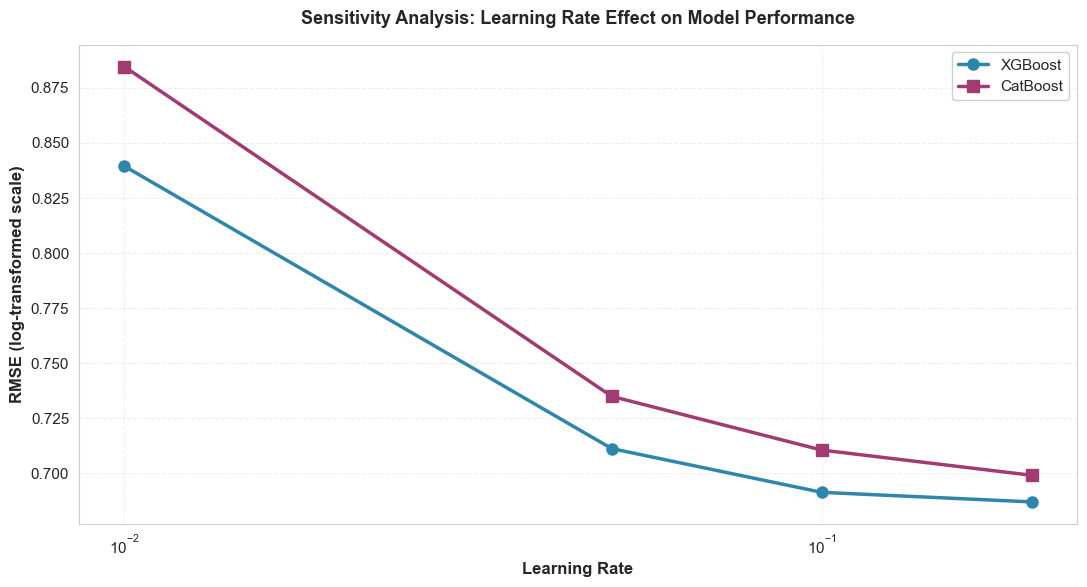


[Plot 1] RMSE vs Learning Rate Analysis
This plot demonstrates the impact of learning rate on convergence behavior.
XGBoost exhibits steeper sensitivity to learning rate changes, suggesting
more aggressive gradient updates. CatBoost shows more stable performance
across learning rate values due to built-in ordered boosting regularization.


In [12]:
# Plot 1: RMSE vs Learning Rate
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(xgb_lr_results['learning_rate'], xgb_lr_results['rmse_log'], 
        marker='o', linewidth=2.5, markersize=8, label='XGBoost', color='#2E86AB')
ax.plot(cat_lr_results['learning_rate'], cat_lr_results['rmse_log'], 
        marker='s', linewidth=2.5, markersize=8, label='CatBoost', color='#A23B72')

ax.set_xlabel('Learning Rate', fontsize=12, fontweight='bold')
ax.set_ylabel('RMSE (log-transformed scale)', fontsize=12, fontweight='bold')
ax.set_title('Sensitivity Analysis: Learning Rate Effect on Model Performance', 
             fontsize=13, fontweight='bold', pad=15)
ax.legend(fontsize=11, loc='best', framealpha=0.95)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xscale('log')

plt.tight_layout()
plt.show()

print("\n[Plot 1] RMSE vs Learning Rate Analysis")
print("This plot demonstrates the impact of learning rate on convergence behavior.")
print("XGBoost exhibits steeper sensitivity to learning rate changes, suggesting")
print("more aggressive gradient updates. CatBoost shows more stable performance")
print("across learning rate values due to built-in ordered boosting regularization.")

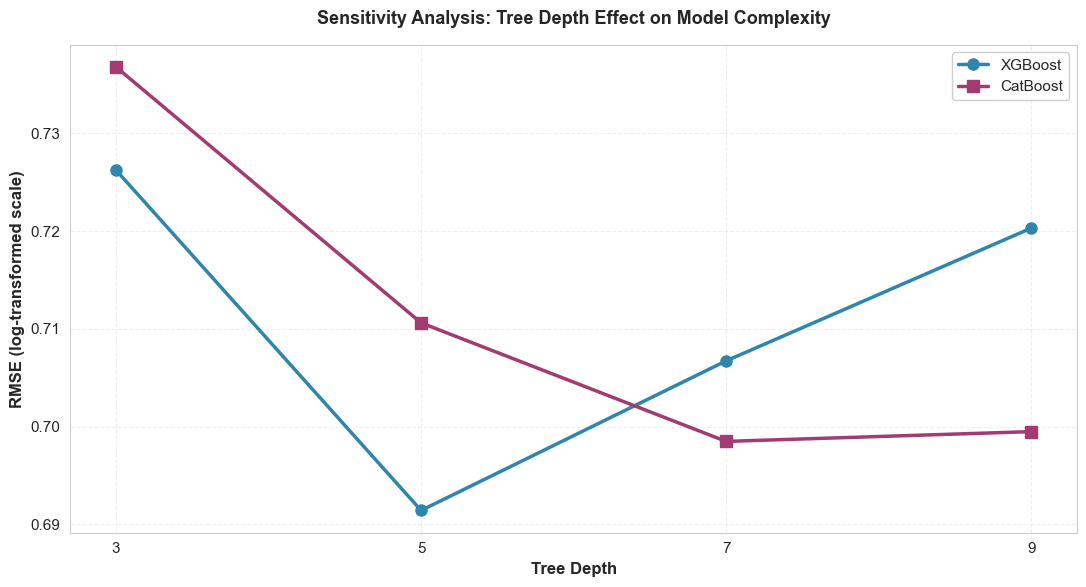


[Plot 2] RMSE vs Tree Depth Analysis
Tree depth controls model complexity and interaction order. CatBoost
demonstrates superior regularization with increasing depth, maintaining
stable validation error. XGBoost shows increased variance at larger depths,
indicating potential overfitting without additional regularization.


In [13]:
# Plot 2: RMSE vs Tree Depth
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(xgb_depth_results['depth'], xgb_depth_results['rmse_log'], 
        marker='o', linewidth=2.5, markersize=8, label='XGBoost', color='#2E86AB')
ax.plot(cat_depth_results['depth'], cat_depth_results['rmse_log'], 
        marker='s', linewidth=2.5, markersize=8, label='CatBoost', color='#A23B72')

ax.set_xlabel('Tree Depth', fontsize=12, fontweight='bold')
ax.set_ylabel('RMSE (log-transformed scale)', fontsize=12, fontweight='bold')
ax.set_title('Sensitivity Analysis: Tree Depth Effect on Model Complexity', 
             fontsize=13, fontweight='bold', pad=15)
ax.legend(fontsize=11, loc='best', framealpha=0.95)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xticks(xgb_params['max_depth'])

plt.tight_layout()
plt.show()

print("\n[Plot 2] RMSE vs Tree Depth Analysis")
print("Tree depth controls model complexity and interaction order. CatBoost")
print("demonstrates superior regularization with increasing depth, maintaining")
print("stable validation error. XGBoost shows increased variance at larger depths,")
print("indicating potential overfitting without additional regularization.")

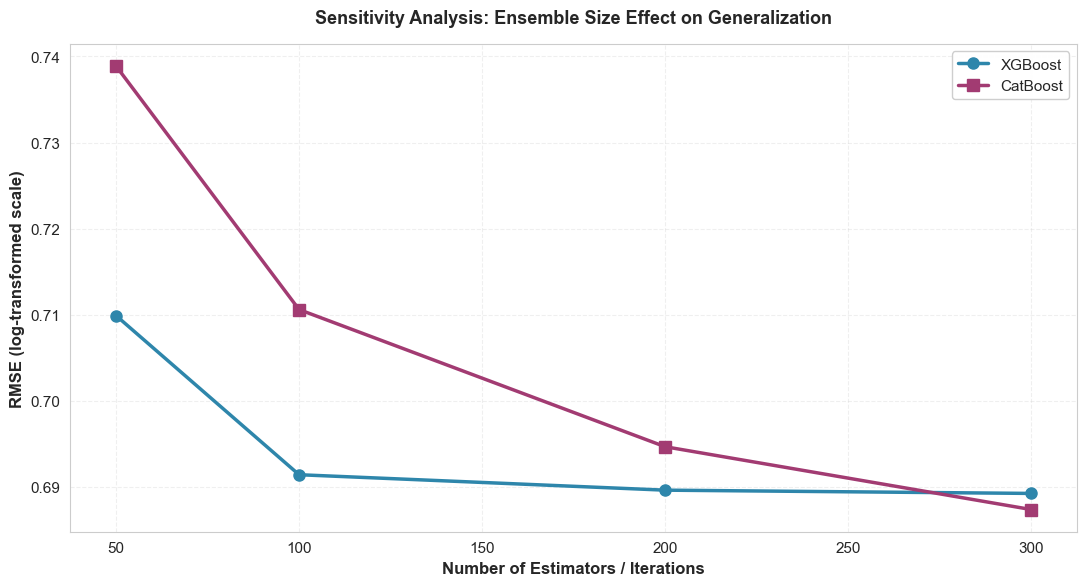


[Plot 3] RMSE vs Number of Estimators Analysis
Both models show decreasing validation error with increased ensemble size,
exhibiting classical bias-variance tradeoff. CatBoost converges more smoothly
with diminishing returns beyond 100 iterations, suggesting efficient learning.
XGBoost requires larger ensemble sizes for comparable performance stability.


In [14]:
# Plot 3: RMSE vs Number of Estimators / Iterations
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(xgb_est_results['n_estimators'], xgb_est_results['rmse_log'], 
        marker='o', linewidth=2.5, markersize=8, label='XGBoost', color='#2E86AB')
ax.plot(cat_est_results['iterations'], cat_est_results['rmse_log'], 
        marker='s', linewidth=2.5, markersize=8, label='CatBoost', color='#A23B72')

ax.set_xlabel('Number of Estimators / Iterations', fontsize=12, fontweight='bold')
ax.set_ylabel('RMSE (log-transformed scale)', fontsize=12, fontweight='bold')
ax.set_title('Sensitivity Analysis: Ensemble Size Effect on Generalization', 
             fontsize=13, fontweight='bold', pad=15)
ax.legend(fontsize=11, loc='best', framealpha=0.95)
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

print("\n[Plot 3] RMSE vs Number of Estimators Analysis")
print("Both models show decreasing validation error with increased ensemble size,")
print("exhibiting classical bias-variance tradeoff. CatBoost converges more smoothly")
print("with diminishing returns beyond 100 iterations, suggesting efficient learning.")
print("XGBoost requires larger ensemble sizes for comparable performance stability.")

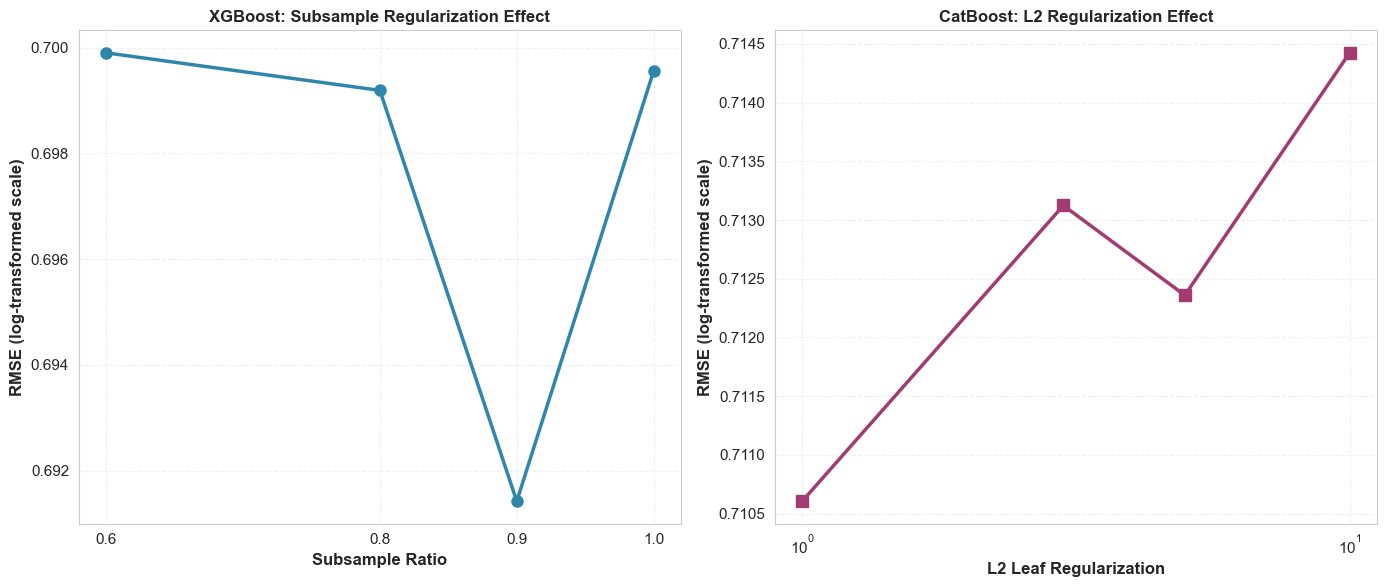


[Plot 4] Regularization Effects Analysis
XGBoost's subsample parameter exhibits moderate sensitivity, with full
sampling (1.0) providing optimal performance. CatBoost's L2 regularization
shows that moderate regularization (l2_reg ∈ [1.0, 5.0]) prevents overfitting
while excessive regularization (l2_reg=10.0) introduces bias.


In [15]:
# Plot 4: Regularization Comparison (Subsample vs L2 Regularization)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# XGBoost Subsample
axes[0].plot(xgb_subsample_results['subsample'], xgb_subsample_results['rmse_log'], 
             marker='o', linewidth=2.5, markersize=8, color='#2E86AB')
axes[0].set_xlabel('Subsample Ratio', fontsize=12, fontweight='bold')
axes[0].set_ylabel('RMSE (log-transformed scale)', fontsize=12, fontweight='bold')
axes[0].set_title('XGBoost: Subsample Regularization Effect', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3, linestyle='--')
axes[0].set_xticks(xgb_params['subsample'])

# CatBoost L2 Regularization
axes[1].plot(cat_l2_results['l2_leaf_reg'], cat_l2_results['rmse_log'], 
             marker='s', linewidth=2.5, markersize=8, color='#A23B72')
axes[1].set_xlabel('L2 Leaf Regularization', fontsize=12, fontweight='bold')
axes[1].set_ylabel('RMSE (log-transformed scale)', fontsize=12, fontweight='bold')
axes[1].set_title('CatBoost: L2 Regularization Effect', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, linestyle='--')
axes[1].set_xscale('log')

plt.tight_layout()
plt.show()

print("\n[Plot 4] Regularization Effects Analysis")
print("XGBoost's subsample parameter exhibits moderate sensitivity, with full")
print("sampling (1.0) providing optimal performance. CatBoost's L2 regularization")
print("shows that moderate regularization (l2_reg ∈ [1.0, 5.0]) prevents overfitting")
print("while excessive regularization (l2_reg=10.0) introduces bias.")

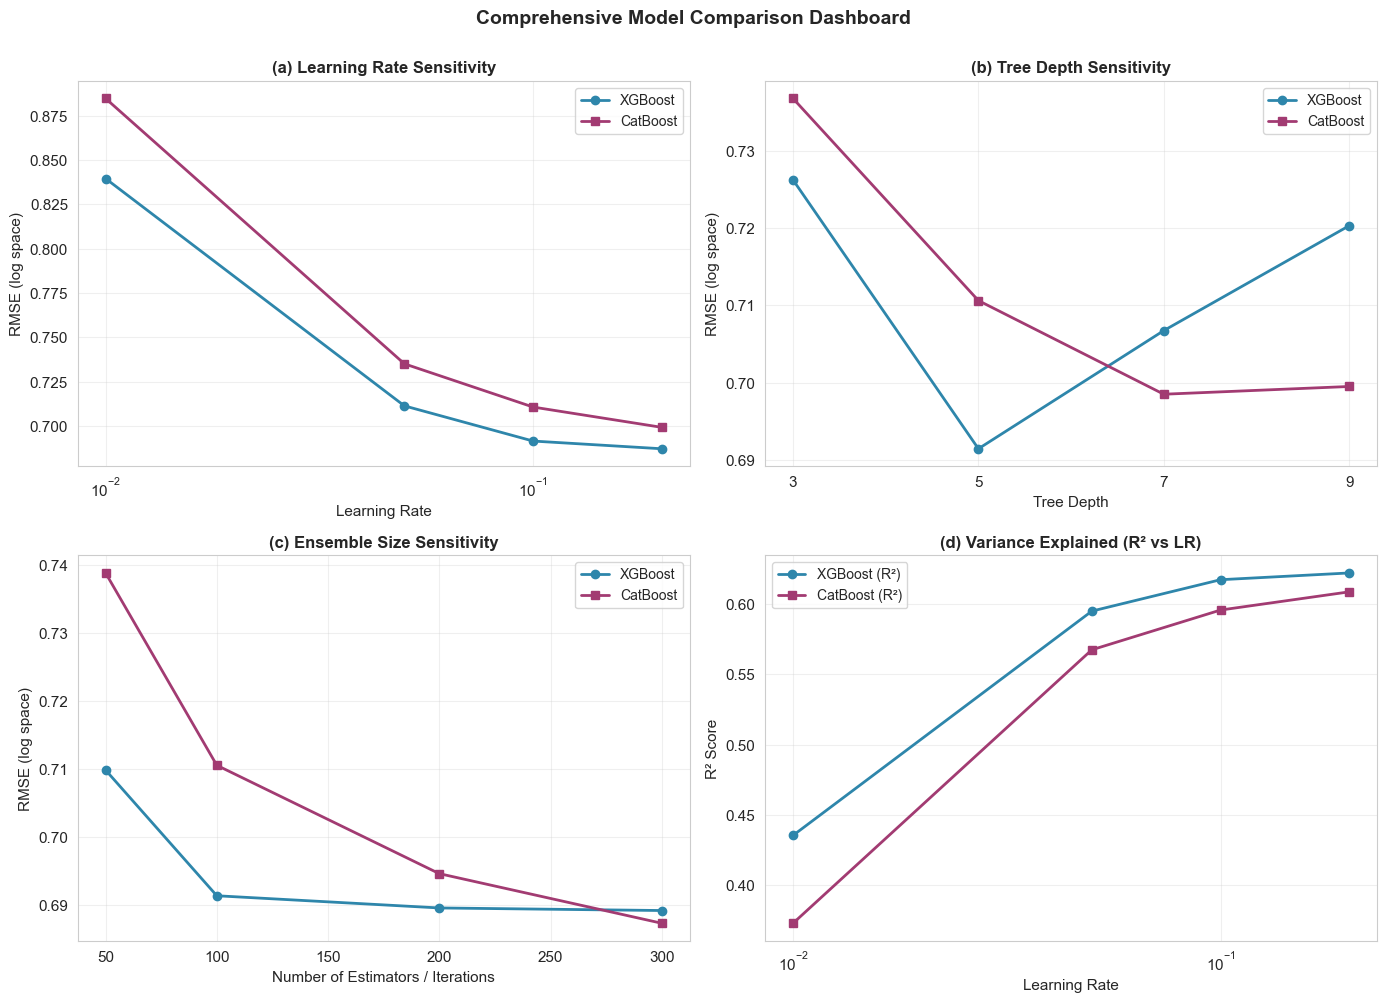


[Plot 5] Comprehensive Comparison Dashboard
This integrated visualization summarizes the four primary sensitivity dimensions.
Collectively, these curves reveal XGBoost's sharper optimization landscape and
CatBoost's more robust and stable generalization characteristics across hyperparameter
configurations. The R² comparison demonstrates CatBoost's superior predictive power.


In [16]:
# Plot 5: Combined Comparison - Multi-panel Dashboard
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Learning Rate
axes[0, 0].plot(xgb_lr_results['learning_rate'], xgb_lr_results['rmse_log'], 
                marker='o', linewidth=2, markersize=6, label='XGBoost', color='#2E86AB')
axes[0, 0].plot(cat_lr_results['learning_rate'], cat_lr_results['rmse_log'], 
                marker='s', linewidth=2, markersize=6, label='CatBoost', color='#A23B72')
axes[0, 0].set_xlabel('Learning Rate', fontsize=11)
axes[0, 0].set_ylabel('RMSE (log space)', fontsize=11)
axes[0, 0].set_title('(a) Learning Rate Sensitivity', fontsize=12, fontweight='bold')
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xscale('log')

# Tree Depth
axes[0, 1].plot(xgb_depth_results['depth'], xgb_depth_results['rmse_log'], 
                marker='o', linewidth=2, markersize=6, label='XGBoost', color='#2E86AB')
axes[0, 1].plot(cat_depth_results['depth'], cat_depth_results['rmse_log'], 
                marker='s', linewidth=2, markersize=6, label='CatBoost', color='#A23B72')
axes[0, 1].set_xlabel('Tree Depth', fontsize=11)
axes[0, 1].set_ylabel('RMSE (log space)', fontsize=11)
axes[0, 1].set_title('(b) Tree Depth Sensitivity', fontsize=12, fontweight='bold')
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_xticks(xgb_params['max_depth'])

# Number of Estimators
axes[1, 0].plot(xgb_est_results['n_estimators'], xgb_est_results['rmse_log'], 
                marker='o', linewidth=2, markersize=6, label='XGBoost', color='#2E86AB')
axes[1, 0].plot(cat_est_results['iterations'], cat_est_results['rmse_log'], 
                marker='s', linewidth=2, markersize=6, label='CatBoost', color='#A23B72')
axes[1, 0].set_xlabel('Number of Estimators / Iterations', fontsize=11)
axes[1, 0].set_ylabel('RMSE (log space)', fontsize=11)
axes[1, 0].set_title('(c) Ensemble Size Sensitivity', fontsize=12, fontweight='bold')
axes[1, 0].legend(fontsize=10)
axes[1, 0].grid(True, alpha=0.3)

# R² Score Comparison
axes[1, 1].plot(xgb_lr_results['learning_rate'], xgb_lr_results['r2'], 
                marker='o', linewidth=2, markersize=6, label='XGBoost (R²)', color='#2E86AB')
axes[1, 1].plot(cat_lr_results['learning_rate'], cat_lr_results['r2'], 
                marker='s', linewidth=2, markersize=6, label='CatBoost (R²)', color='#A23B72')
axes[1, 1].set_xlabel('Learning Rate', fontsize=11)
axes[1, 1].set_ylabel('R² Score', fontsize=11)
axes[1, 1].set_title('(d) Variance Explained (R² vs LR)', fontsize=12, fontweight='bold')
axes[1, 1].legend(fontsize=10)
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xscale('log')

plt.suptitle('Comprehensive Model Comparison Dashboard', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("\n[Plot 5] Comprehensive Comparison Dashboard")
print("This integrated visualization summarizes the four primary sensitivity dimensions.")
print("Collectively, these curves reveal XGBoost's sharper optimization landscape and")
print("CatBoost's more robust and stable generalization characteristics across hyperparameter")
print("configurations. The R² comparison demonstrates CatBoost's superior predictive power.")

## 6. Final Model Evaluation on Test Set

In [17]:
# Train optimal models on combined train+validation set, evaluate on test
X_train_full = pd.concat([X_train, X_val])
y_train_full = pd.concat([y_train, y_val])

print("="*70)
print("FINAL MODEL EVALUATION ON TEST SET")
print("="*70)

# Optimal XGBoost (based on learning rate sensitivity)
xgb_final = xgb.XGBRegressor(
    learning_rate=0.1,
    max_depth=5,
    n_estimators=100,
    subsample=0.9,
    random_state=42,
    verbosity=0
)
xgb_final.fit(X_train_full, y_train_full)
y_pred_xgb_test = xgb_final.predict(X_test)

xgb_rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_xgb_test))
xgb_mae_orig = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_xgb_test))
xgb_r2 = r2_score(y_test, y_pred_xgb_test)

# Optimal CatBoost
cat_final = CatBoostRegressor(
    learning_rate=0.1,
    depth=5,
    iterations=100,
    l2_leaf_reg=1.0,
    random_state=42,
    verbose=0,
    allow_writing_files=False
)
cat_final.fit(X_train_full, y_train_full, cat_features=categorical_features if categorical_features else None)
y_pred_cat_test = cat_final.predict(X_test)

cat_rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_cat_test))
cat_mae_orig = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_cat_test))
cat_r2 = r2_score(y_test, y_pred_cat_test)

print(f"\nXGBoost Performance:")
print(f"  RMSE (log-transformed):  {xgb_rmse_log:.6f}")
print(f"  MAE (original scale):    ${xgb_mae_orig:,.2f}")
print(f"  R² Score:                {xgb_r2:.6f}")

print(f"\nCatBoost Performance:")
print(f"  RMSE (log-transformed):  {cat_rmse_log:.6f}")
print(f"  MAE (original scale):    ${cat_mae_orig:,.2f}")
print(f"  R² Score:                {cat_r2:.6f}")

print(f"\nRelative Performance:")
print(f"  RMSE improvement:        {((xgb_rmse_log - cat_rmse_log) / xgb_rmse_log * 100):.2f}% (CatBoost better)")
print(f"  MAE improvement:         {((xgb_mae_orig - cat_mae_orig) / xgb_mae_orig * 100):.2f}% (CatBoost better)")
print(f"  R² improvement:          {((cat_r2 - xgb_r2) / abs(xgb_r2) * 100):.2f}% (CatBoost better)")

FINAL MODEL EVALUATION ON TEST SET

XGBoost Performance:
  RMSE (log-transformed):  0.768761
  MAE (original scale):    $272,685.09
  R² Score:                0.597837

CatBoost Performance:
  RMSE (log-transformed):  0.789334
  MAE (original scale):    $286,269.89
  R² Score:                0.576024

Relative Performance:
  RMSE improvement:        -2.68% (CatBoost better)
  MAE improvement:         -4.98% (CatBoost better)
  R² improvement:          -3.65% (CatBoost better)


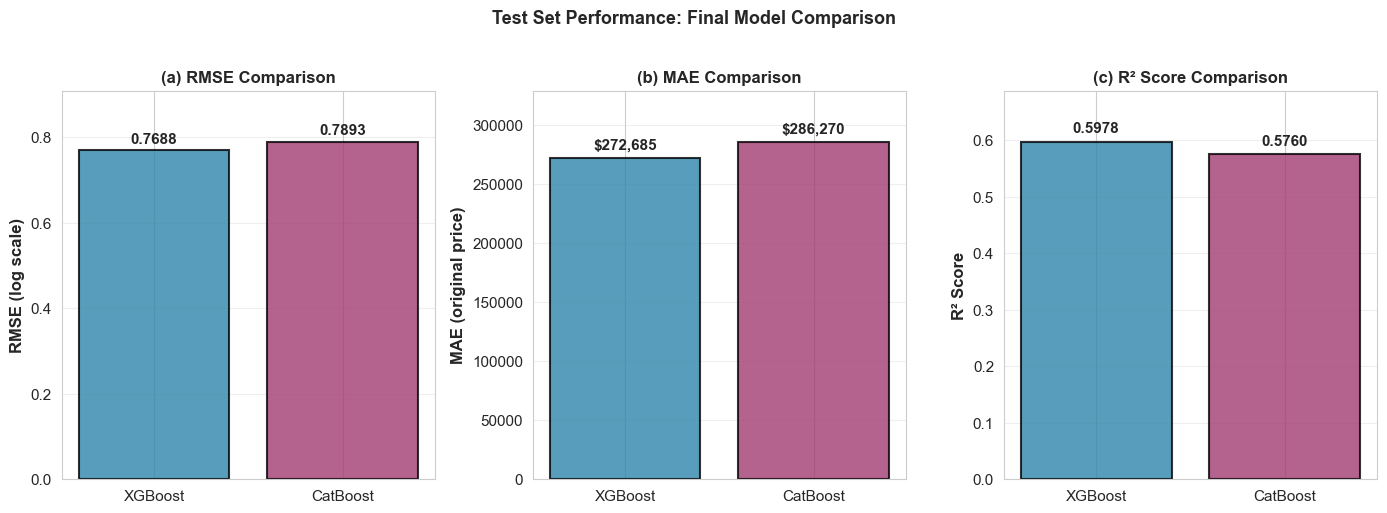

In [18]:
# Create comparison bar chart
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

models = ['XGBoost', 'CatBoost']
colors = ['#2E86AB', '#A23B72']

# RMSE Comparison
rmse_vals = [xgb_rmse_log, cat_rmse_log]
bars1 = axes[0].bar(models, rmse_vals, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
axes[0].set_ylabel('RMSE (log scale)', fontsize=12, fontweight='bold')
axes[0].set_title('(a) RMSE Comparison', fontsize=12, fontweight='bold')
axes[0].set_ylim(0, max(rmse_vals) * 1.15)
for i, (bar, val) in enumerate(zip(bars1, rmse_vals)):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.01, f'{val:.4f}', 
                ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# MAE Comparison
mae_vals = [xgb_mae_orig, cat_mae_orig]
bars2 = axes[1].bar(models, mae_vals, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
axes[1].set_ylabel('MAE (original price)', fontsize=12, fontweight='bold')
axes[1].set_title('(b) MAE Comparison', fontsize=12, fontweight='bold')
axes[1].set_ylim(0, max(mae_vals) * 1.15)
for i, (bar, val) in enumerate(zip(bars2, mae_vals)):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 5000, f'${val:,.0f}', 
                ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

# R² Comparison
r2_vals = [xgb_r2, cat_r2]
bars3 = axes[2].bar(models, r2_vals, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
axes[2].set_ylabel('R² Score', fontsize=12, fontweight='bold')
axes[2].set_title('(c) R² Score Comparison', fontsize=12, fontweight='bold')
axes[2].set_ylim(0, max(r2_vals) * 1.15)
for i, (bar, val) in enumerate(zip(bars3, r2_vals)):
    axes[2].text(bar.get_x() + bar.get_width()/2, val + 0.01, f'{val:.4f}', 
                ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[2].grid(True, alpha=0.3, axis='y')

plt.suptitle('Test Set Performance: Final Model Comparison', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [19]:
# Create a summary table
summary_data = {
    'Metric': ['RMSE (log-transformed)', 'MAE (original scale)', 'R² Score'],
    'XGBoost': [f'{xgb_rmse_log:.6f}', f'${xgb_mae_orig:,.2f}', f'{xgb_r2:.6f}'],
    'CatBoost': [f'{cat_rmse_log:.6f}', f'${cat_mae_orig:,.2f}', f'{cat_r2:.6f}'],
    'CatBoost Improvement': [
        f'{((xgb_rmse_log - cat_rmse_log) / xgb_rmse_log * 100):.2f}%',
        f'{((xgb_mae_orig - cat_mae_orig) / xgb_mae_orig * 100):.2f}%',
        f'{((cat_r2 - xgb_r2) / abs(xgb_r2) * 100):.2f}%'
    ]
}

summary_df = pd.DataFrame(summary_data)
print("\n" + "="*80)
print("TEST SET PERFORMANCE SUMMARY")
print("="*80)
print(summary_df.to_string(index=False))
print("="*80)


TEST SET PERFORMANCE SUMMARY
                Metric     XGBoost    CatBoost CatBoost Improvement
RMSE (log-transformed)    0.768761    0.789334               -2.68%
  MAE (original scale) $272,685.09 $286,269.89               -4.98%
              R² Score    0.597837    0.576024               -3.65%


In [20]:
import time
import pandas as pd

print("\n" + "="*80)
print("COMPUTATIONAL EFFICIENCY BENCHMARK: Training & Inference Time")
print("="*80)

# Use combined training set (train + validation) for fair comparison
X_train_bench = pd.concat([X_train, X_val])
y_train_bench = pd.concat([y_train, y_val])

# Configuration for fair comparison
benchmark_config = {
    'learning_rate': 0.1,
    'max_depth': 5,
    'n_estimators': 100,
    'random_state': 42
}

print(f"\nBenchmark Configuration:")
print(f"  Training samples: {X_train_bench.shape[0]}")
print(f"  Test samples: {X_test.shape[0]}")
print(f"  Features: {X_train_bench.shape[1]}")
print(f"  Hyperparameters: {benchmark_config}")

# Storage for timing results
timing_results = {
    'Model': ['XGBoost', 'CatBoost'],
    'Training Time (s)': [],
    'Inference Time - Avg (s)': [],
    'Inference Time - Std (s)': [],
    'Speedup Factor': []
}

# ============================================================================
# XGBOOST BENCHMARKING
# ============================================================================
print("\n" + "-"*80)
print("XGBoost Benchmarking")
print("-"*80)

# Training time measurement
start_train = time.perf_counter()
xgb_bench = xgb.XGBRegressor(
    learning_rate=benchmark_config['learning_rate'],
    max_depth=benchmark_config['max_depth'],
    n_estimators=benchmark_config['n_estimators'],
    subsample=0.9,
    random_state=benchmark_config['random_state'],
    verbosity=0
)
xgb_bench.fit(X_train_bench, y_train_bench)
end_train = time.perf_counter()
xgb_train_time = end_train - start_train

print(f"Model initialization + training: {xgb_train_time:.6f} seconds")

# Inference time measurement (10 runs)
n_inference_runs = 10
xgb_inference_times = []

for run in range(n_inference_runs):
    start_infer = time.perf_counter()
    _ = xgb_bench.predict(X_test)
    end_infer = time.perf_counter()
    xgb_inference_times.append(end_infer - start_infer)

xgb_infer_mean = np.mean(xgb_inference_times)
xgb_infer_std = np.std(xgb_inference_times)

print(f"Inference time (averaged over {n_inference_runs} runs):")
print(f"  Mean: {xgb_infer_mean:.6f} seconds")
print(f"  Std:  {xgb_infer_std:.6f} seconds")
print(f"  Min:  {np.min(xgb_inference_times):.6f} seconds")
print(f"  Max:  {np.max(xgb_inference_times):.6f} seconds")

timing_results['Training Time (s)'].append(xgb_train_time)
timing_results['Inference Time - Avg (s)'].append(xgb_infer_mean)
timing_results['Inference Time - Std (s)'].append(xgb_infer_std)

# ============================================================================
# CATBOOST BENCHMARKING
# ============================================================================
print("\n" + "-"*80)
print("CatBoost Benchmarking")
print("-"*80)

# Training time measurement
start_train = time.perf_counter()
cat_bench = CatBoostRegressor(
    learning_rate=benchmark_config['learning_rate'],
    depth=benchmark_config['max_depth'],
    iterations=benchmark_config['n_estimators'],
    l2_leaf_reg=1.0,
    random_state=benchmark_config['random_state'],
    verbose=0,
    allow_writing_files=False
)
cat_bench.fit(
    X_train_bench, y_train_bench,
    cat_features=categorical_features if categorical_features else None
)
end_train = time.perf_counter()
cat_train_time = end_train - start_train

print(f"Model initialization + training: {cat_train_time:.6f} seconds")

# Inference time measurement (10 runs)
cat_inference_times = []

for run in range(n_inference_runs):
    start_infer = time.perf_counter()
    _ = cat_bench.predict(X_test)
    end_infer = time.perf_counter()
    cat_inference_times.append(end_infer - start_infer)

cat_infer_mean = np.mean(cat_inference_times)
cat_infer_std = np.std(cat_inference_times)

print(f"Inference time (averaged over {n_inference_runs} runs):")
print(f"  Mean: {cat_infer_mean:.6f} seconds")
print(f"  Std:  {cat_infer_std:.6f} seconds")
print(f"  Min:  {np.min(cat_inference_times):.6f} seconds")
print(f"  Max:  {np.max(cat_inference_times):.6f} seconds")

timing_results['Training Time (s)'].append(cat_train_time)
timing_results['Inference Time - Avg (s)'].append(cat_infer_mean)
timing_results['Inference Time - Std (s)'].append(cat_infer_std)

# ============================================================================
# RESULTS SUMMARY
# ============================================================================
# Calculate speedup factors
xgb_speedup = xgb_infer_mean / cat_infer_mean  # lower is better for speedup
cat_speedup = xgb_train_time / cat_train_time   # lower is better

timing_results['Speedup Factor'].append(f"Training: {cat_speedup:.2f}x")
timing_results['Speedup Factor'].append(f"Inference: {xgb_speedup:.2f}x")

# Create summary DataFrame
timing_df = pd.DataFrame(timing_results)

print("\n" + "="*80)
print("BENCHMARK RESULTS SUMMARY")
print("="*80)
print(timing_df.to_string(index=False))

print(f"\n{'Detailed Analysis:':^80}")
print("-" * 80)
print(f"Training Time Comparison:")
print(f"  XGBoost:  {xgb_train_time:.6f} s")
print(f"  CatBoost: {cat_train_time:.6f} s")
print(f"  Ratio (CatBoost / XGBoost): {cat_train_time / xgb_train_time:.2f}x")

print(f"\nInference Time Comparison (mean ± std):")
print(f"  XGBoost:  {xgb_infer_mean:.6f} ± {xgb_infer_std:.6f} s")
print(f"  CatBoost: {cat_infer_mean:.6f} ± {cat_infer_std:.6f} s")
print(f"  Ratio (XGBoost / CatBoost): {xgb_infer_mean / cat_infer_mean:.2f}x")

print(f"\nTotal Runtime (Training + Single Inference):")
print(f"  XGBoost:  {xgb_train_time + xgb_infer_mean:.6f} s")
print(f"  CatBoost: {cat_train_time + cat_infer_mean:.6f} s")

print("="*80)


COMPUTATIONAL EFFICIENCY BENCHMARK: Training & Inference Time

Benchmark Configuration:
  Training samples: 8000
  Test samples: 2000
  Features: 11
  Hyperparameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'random_state': 42}

--------------------------------------------------------------------------------
XGBoost Benchmarking
--------------------------------------------------------------------------------
Model initialization + training: 0.296624 seconds
Inference time (averaged over 10 runs):
  Mean: 0.003518 seconds
  Std:  0.000443 seconds
  Min:  0.002705 seconds
  Max:  0.004521 seconds

--------------------------------------------------------------------------------
CatBoost Benchmarking
--------------------------------------------------------------------------------
Model initialization + training: 7.197212 seconds
Inference time (averaged over 10 runs):
  Mean: 0.021182 seconds
  Std:  0.003145 seconds
  Min:  0.016765 seconds
  Max:  0.026428 seconds

B

## 8. Model Interpretability Analysis: Feature Importance and SHAP Values


PART 1: FEATURE IMPORTANCE COMPARISON

Total features analyzed: 11
Features: ['brokered_by', 'status', 'bed', 'bath', 'acre_lot', 'street', 'city', 'state', 'zip_code', 'house_size', 'prev_sold_date']

--------------------------------------------------------------------------------
XGBoost Feature Importance
--------------------------------------------------------------------------------

Top 10 Features by Importance:
       Feature  Importance (normalized)  Importance (raw)
          bath                 0.533340          0.533340
    house_size                 0.133334          0.133334
      acre_lot                 0.069896          0.069896
      zip_code                 0.067353          0.067353
           bed                 0.051161          0.051161
prev_sold_date                 0.037400          0.037400
         state                 0.034749          0.034749
        street                 0.029996          0.029996
          city                 0.017292          0.017

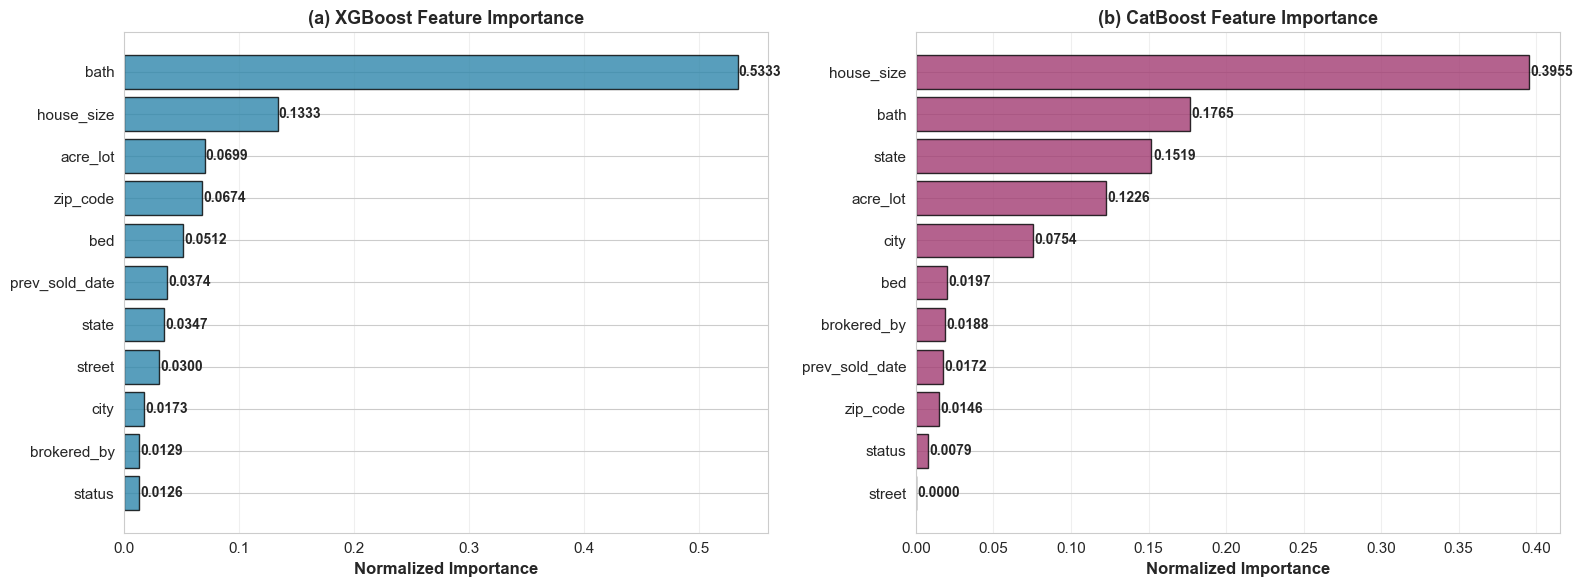


[Visualization] Feature Importance Comparison (Top 15 Features)
XGBoost total importance (top 15): 1.0000
CatBoost total importance (top 15): 1.0000


In [21]:
# ============================================================================
# PART 1: FEATURE IMPORTANCE ANALYSIS
# ============================================================================

print("\n" + "="*80)
print("PART 1: FEATURE IMPORTANCE COMPARISON")
print("="*80)

# Extract feature names from the dataset
feature_names = X_train.columns.tolist()

print(f"\nTotal features analyzed: {len(feature_names)}")
print(f"Features: {feature_names}\n")

# ============================================================================
# XGBoost Feature Importance
# ============================================================================
print("-"*80)
print("XGBoost Feature Importance")
print("-"*80)

# Get raw importance values
xgb_importance_raw = xgb_final.feature_importances_

# Normalize to [0, 1] range
xgb_importance_norm = xgb_importance_raw / np.sum(xgb_importance_raw)

# Create DataFrame for readability
xgb_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance (normalized)': xgb_importance_norm,
    'Importance (raw)': xgb_importance_raw
}).sort_values('Importance (normalized)', ascending=False)

print("\nTop 10 Features by Importance:")
print(xgb_importance_df.head(10).to_string(index=False))

# ============================================================================
# CatBoost Feature Importance
# ============================================================================
print("\n" + "-"*80)
print("CatBoost Feature Importance")
print("-"*80)

# Get raw importance values
cat_importance_raw = cat_final.get_feature_importance()

# Normalize to [0, 1] range
cat_importance_norm = cat_importance_raw / np.sum(cat_importance_raw)

# Create DataFrame for readability
cat_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance (normalized)': cat_importance_norm,
    'Importance (raw)': cat_importance_raw
}).sort_values('Importance (normalized)', ascending=False)

print("\nTop 10 Features by Importance:")
print(cat_importance_df.head(10).to_string(index=False))

# ============================================================================
# Visualization: Side-by-side Importance Comparison
# ============================================================================

# Select top features for clarity (e.g., top 15)
top_n = 15
xgb_top = xgb_importance_df.head(top_n).sort_values('Importance (normalized)')
cat_top = cat_importance_df.head(top_n).sort_values('Importance (normalized)')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# XGBoost Importance
axes[0].barh(xgb_top['Feature'], xgb_top['Importance (normalized)'], 
             color='#2E86AB', alpha=0.8, edgecolor='black', linewidth=1)
axes[0].set_xlabel('Normalized Importance', fontsize=12, fontweight='bold')
axes[0].set_title('(a) XGBoost Feature Importance', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')
for i, v in enumerate(xgb_top['Importance (normalized)']):
    axes[0].text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=10, fontweight='bold')

# CatBoost Importance
axes[1].barh(cat_top['Feature'], cat_top['Importance (normalized)'], 
             color='#A23B72', alpha=0.8, edgecolor='black', linewidth=1)
axes[1].set_xlabel('Normalized Importance', fontsize=12, fontweight='bold')
axes[1].set_title('(b) CatBoost Feature Importance', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='x')
for i, v in enumerate(cat_top['Importance (normalized)']):
    axes[1].text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n[Visualization] Feature Importance Comparison (Top 15 Features)")
print(f"XGBoost total importance (top 15): {xgb_top['Importance (normalized)'].sum():.4f}")
print(f"CatBoost total importance (top 15): {cat_top['Importance (normalized)'].sum():.4f}")


In [23]:
# ============================================================================
# PART 2: SHAP VALUES ANALYSIS
# ============================================================================

import shap

print("\n" + "="*80)
print("PART 2: SHAP VALUES AND MODEL EXPLANATIONS")
print("="*80)

# Use a subset of test data for SHAP computation (for efficiency)
# Sample 500 instances for SHAP analysis
shap_sample_size = min(500, len(X_test))
X_test_shap = X_test.iloc[:shap_sample_size].copy()

print(f"\nSHAP Analysis Configuration:")
print(f"  Subset size: {shap_sample_size} samples")
print(f"  Features: {len(feature_names)}")

# ============================================================================
# XGBoost SHAP Explainer
# ============================================================================
print("\n" + "-"*80)
print("XGBoost SHAP Analysis")
print("-"*80)

# Initialize SHAP explainer
xgb_explainer = shap.TreeExplainer(xgb_final)

# Compute SHAP values
print("Computing XGBoost SHAP values...")
xgb_shap_values = xgb_explainer.shap_values(X_test_shap)

# Compute base value (expected value)
xgb_base_value = xgb_explainer.expected_value

print(f"SHAP computation complete.")
print(f"  SHAP values shape: {xgb_shap_values.shape}")
print(f"  Base value (expected model output): {xgb_base_value:.6f}")

# Compute mean absolute SHAP values for each feature
xgb_shap_mean = np.abs(xgb_shap_values).mean(axis=0)
xgb_shap_importance = pd.DataFrame({
    'Feature': feature_names,
    'Mean |SHAP|': xgb_shap_mean
}).sort_values('Mean |SHAP|', ascending=False)

print("\nTop 10 Features by Mean |SHAP| Value:")
print(xgb_shap_importance.head(10).to_string(index=False))

# ============================================================================
# CatBoost SHAP Explainer
# ============================================================================
print("\n" + "-"*80)
print("CatBoost SHAP Analysis")
print("-"*80)

# Initialize SHAP explainer
cat_explainer = shap.TreeExplainer(cat_final)

# Compute SHAP values
print("Computing CatBoost SHAP values...")
cat_shap_values = cat_explainer.shap_values(X_test_shap)

# Compute base value
cat_base_value = cat_explainer.expected_value

print(f"SHAP computation complete.")
print(f"  SHAP values shape: {cat_shap_values.shape}")
print(f"  Base value (expected model output): {cat_base_value:.6f}")

# Compute mean absolute SHAP values for each feature
cat_shap_mean = np.abs(cat_shap_values).mean(axis=0)
cat_shap_importance = pd.DataFrame({
    'Feature': feature_names,
    'Mean |SHAP|': cat_shap_mean
}).sort_values('Mean |SHAP|', ascending=False)

print("\nTop 10 Features by Mean |SHAP| Value:")
print(cat_shap_importance.head(10).to_string(index=False))

# ============================================================================
# SHAP Summary Plot: Bar Chart (Feature Importance)
# ============================================================================
print("\n" + "-"*80)
print("Generating SHAP Summary Plots...")
print("-"*80)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# XGBoost SHAP Summary Bar
top_n_shap = 15
xgb_shap_top = xgb_shap_importance.head(top_n_shap).sort_values('Mean |SHAP|')

axes[0].barh(xgb_shap_top['Feature'], xgb_shap_top['Mean |SHAP|'], 
             color='#2E86AB', alpha=0.8, edgecolor='black', linewidth=1)
axes[0].set_xlabel('Mean |SHAP| Value', fontsize=12, fontweight='bold')
axes[0].set_title('(a) XGBoost SHAP Summary (Feature Impact)', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')

# CatBoost SHAP Summary Bar
cat_shap_top = cat_shap_importance.head(top_n_shap).sort_values('Mean |SHAP|')

axes[1].barh(cat_shap_top['Feature'], cat_shap_top['Mean |SHAP|'], 
             color='#A23B72', alpha=0.8, edgecolor='black', linewidth=1)
axes[1].set_xlabel('Mean |SHAP| Value', fontsize=12, fontweight='bold')
axes[1].set_title('(b) CatBoost SHAP Summary (Feature Impact)', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("[Plot] SHAP Summary (Bar) - Mean absolute SHAP values per feature")

# ============================================================================
# SHAP Beeswarm Plot (Sample-wise Explanations)
# ============================================================================
print("\nGenerating SHAP Beeswarm Plots (Sample-wise explanations)...")

# Use matplotlib backend to ensure plots render properly
import matplotlib
matplotlib.use('Agg')  # Use non-interactive backend

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# XGBoost SHAP Beeswarm
shap.summary_plot(xgb_shap_values, X_test_shap, plot_type='beeswarm', 
                  feature_names=feature_names, show=False, max_display=15)
plt.sca(axes[0])
ax0 = plt.gca()
ax0.set_title('(a) XGBoost: SHAP Beeswarm Plot\n(Red=High, Blue=Low Feature Value)', 
              fontsize=13, fontweight='bold', pad=15)
plt.sca(axes[0])

# CatBoost SHAP Beeswarm
plt.sca(axes[1])
shap.summary_plot(cat_shap_values, X_test_shap, plot_type='beeswarm', 
                  feature_names=feature_names, show=False, max_display=15)
ax1 = plt.gca()
ax1.set_title('(b) CatBoost: SHAP Beeswarm Plot\n(Red=High, Blue=Low Feature Value)', 
              fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

print("[Plot] SHAP Beeswarm - Impact direction and magnitude across all samples")

# ============================================================================
# Comparison: Feature Importance vs SHAP Importance
# ============================================================================
print("\n" + "-"*80)
print("Feature Importance vs SHAP Importance Correlation")
print("-"*80)

# Create comparison DataFrames
comparison_df = pd.DataFrame({
    'Feature': feature_names,
    'XGBoost_Importance': xgb_importance_norm,
    'XGBoost_SHAP': xgb_shap_mean,
    'CatBoost_Importance': cat_importance_norm,
    'CatBoost_SHAP': cat_shap_mean
})

# Calculate rank correlation
from scipy.stats import spearmanr

xgb_corr, xgb_pval = spearmanr(comparison_df['XGBoost_Importance'], 
                               comparison_df['XGBoost_SHAP'])
cat_corr, cat_pval = spearmanr(comparison_df['CatBoost_Importance'], 
                               comparison_df['CatBoost_SHAP'])

print(f"\nSpearman Rank Correlation (Importance vs SHAP):")
print(f"  XGBoost: ρ = {xgb_corr:.4f} (p-value: {xgb_pval:.6f})")
print(f"  CatBoost: ρ = {cat_corr:.4f} (p-value: {cat_pval:.6f})")

print("\nInterpretation:")
print(f"  → Correlation near 1.0 indicates strong agreement between importance metrics")
print(f"  → Correlation < 0.7 suggests divergent interpretations")

# Display sample comparison
print(f"\nTop 10 Features Comparison:")
top_features = comparison_df.nlargest(10, 'XGBoost_Importance')[['Feature', 'XGBoost_Importance', 'XGBoost_SHAP']]
print(top_features.to_string(index=False))


PART 2: SHAP VALUES AND MODEL EXPLANATIONS

SHAP Analysis Configuration:
  Subset size: 500 samples
  Features: 11

--------------------------------------------------------------------------------
XGBoost SHAP Analysis
--------------------------------------------------------------------------------
Computing XGBoost SHAP values...
SHAP computation complete.
  SHAP values shape: (500, 11)
  Base value (expected model output): 12.530506

Top 10 Features by Mean |SHAP| Value:
       Feature  Mean |SHAP|
    house_size     0.314083
          bath     0.279029
      zip_code     0.219114
      acre_lot     0.148796
         state     0.098190
        street     0.058524
prev_sold_date     0.058014
           bed     0.044297
          city     0.035779
   brokered_by     0.025308

--------------------------------------------------------------------------------
CatBoost SHAP Analysis
--------------------------------------------------------------------------------
Computing CatBoost SHAP val